# Experiment №6
## All 4 conditions for orthogonality are met (same as Experiment №1).

- Left tower: Single linear layer (nn.Linear) with one-hot input
- Right tower: Item embedding layer (nn.Embedding)
- Cosine-based loss is used: InfoNCE
- SGD without momentum and without regularization

I visualize user vs item embedding shifts in 2D and measure orthogonality of updates.

## 1) Setup and configuration

In [1]:
import math
import random

import numpy as np
import pandas as pd
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from info_nce import InfoNCE # pip install info-nce-pytorch


torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## 2) Toy dataset

I use a tiny synthetic dataset to make geometric effects interpretable. Users 5, 6, 7 share items 5i*, 6i*, creating a small connectivity component; others are isolated.


In [2]:
# Toy data — simple connectivity structure for clean geometry
# Users 5, 6, 7 share items 5i*, 6i*, creating a small connectivity component; others are isolated
train = pd.DataFrame([], columns=["user_id", "item_id"])

train.loc[len(train)] = ["1u", "1i1"]
train.loc[len(train)] = ["1u", "1i2"]
train.loc[len(train)] = ["1u", "1i3"]
train.loc[len(train)] = ["2u", "2i1"]
train.loc[len(train)] = ["2u", "2i2"]
train.loc[len(train)] = ["2u", "2i3"]
train.loc[len(train)] = ["3u", "3i1"]
train.loc[len(train)] = ["3u", "3i2"]
train.loc[len(train)] = ["3u", "3i3"]
train.loc[len(train)] = ["4u", "4i1"]
train.loc[len(train)] = ["4u", "4i2"]
train.loc[len(train)] = ["4u", "4i3"]
train.loc[len(train)] = ["5u", "5i1"]
train.loc[len(train)] = ["5u", "5i2"]
train.loc[len(train)] = ["5u", "5i3"]
train.loc[len(train)] = ["6u", "6i1"]
train.loc[len(train)] = ["6u", "6i2"]
train.loc[len(train)] = ["6u", "6i3"]
train.loc[len(train)] = ["7u", "5i1"]
train.loc[len(train)] = ["7u", "5i2"]
train.loc[len(train)] = ["7u", "5i3"]
train.loc[len(train)] = ["7u", "5i4"]
train.loc[len(train)] = ["7u", "6i1"]
train.loc[len(train)] = ["7u", "6i2"]
train.loc[len(train)] = ["7u", "6i3"]

## 3) Dataloader

In [3]:
user_encoder = LabelEncoder().fit(train["user_id"])
item_encoder = LabelEncoder().fit(train["item_id"])

In [4]:
class TwoTowerDataset(Dataset):

    def __init__(self,
                 positive_interactions_dataframe,
                 user_encoder, 
                 item_encoder
                ):
        self.positive_interactions_dataframe = \
        positive_interactions_dataframe.copy()
        
        self.positive_interactions_dataframe["encoded_user_id"] = \
        user_encoder.transform(self.positive_interactions_dataframe.user_id)
        self.positive_interactions_dataframe["encoded_item_id"] = \
        item_encoder.transform(self.positive_interactions_dataframe.item_id)
        
        self.user2features = {}
        self.item2features = {}
        self.interactions_features_list = []

        for row in tqdm(self.positive_interactions_dataframe.itertuples()):
            self.interactions_features_list.append(
                (
                    (row.encoded_user_id,),
                    (row.encoded_item_id,)
                )
            )
            if row.user_id not in self.user2features:
                self.user2features[row.user_id] = (row.encoded_user_id,)

            if row.item_id not in self.item2features:
                self.item2features[row.item_id] = (row.encoded_item_id,)

        self.start = 0
        self.end = len(self.interactions_features_list)
    
    def __len__(self):
        return len(self.interactions_features_list)
    
    def __getitem__(self, i):
        return self.interactions_features_list[i]


train_dataset = TwoTowerDataset(train, user_encoder, item_encoder)

N_USERS = len(user_encoder.classes_)
N_ITEMS = len(item_encoder.classes_)

def collate_fn(batch):
    users_features, items_features = zip(*batch)

    user_indices = torch.IntTensor(np.array(users_features)).squeeze(1)
    item_indices = torch.IntTensor(np.array(items_features)).squeeze(1)

    user_one_hot = F.one_hot(user_indices.long(), num_classes=N_USERS).float()
    item_one_hot = F.one_hot(item_indices.long(), num_classes=N_ITEMS).float()

    return (user_one_hot, item_one_hot)

train_loader = DataLoader(
    train_dataset,
    batch_size=len(train_dataset),
    collate_fn=collate_fn
)

25it [00:00, 335008.31it/s]


In [5]:
print(f'Batch shape: \n')

some_batch = next(iter(train_loader))

some_batch[0].shape, some_batch[1].shape

Batch shape: 



(torch.Size([25, 7]), torch.Size([25, 19]))

## 4) Model (Two-Tower)

In [6]:
class TwoTowerModel(nn.Module):
    def __init__(self, user_embedding_sizes, item_embedding_sizes, device):
        super(TwoTowerModel, self).__init__()
        self.device = device

        self.user_linear = nn.Linear(
            user_embedding_sizes[0], 
            user_embedding_sizes[1],
            bias=False
        )
        self.item_linear = nn.Linear(
            item_embedding_sizes[0], 
            item_embedding_sizes[1],
            bias=False
        )

    def get_user_embeddings(self, user_features):
        user_embeddings = self.user_linear(user_features)

        return user_embeddings

    def get_item_embeddings(self, item_features):
        item_embeddings = self.item_linear(item_features)

        return item_embeddings

    def forward(self, user_features, item_features):
        user_embs = self.get_user_embeddings(user_features.to(self.device))
        item_embs = self.get_item_embeddings(item_features.to(self.device))

        return user_embs, item_embs

## 5) Training and visualization

In [7]:
infonceloss = InfoNCE(temperature=1)

# Tracking utilities (separate user/item stats)

def plot_embedding_shift(
    old_users_embeddings,
    old_items_embeddings,
    new_users_embeddings,
    new_items_embeddings,
    users_ids,
    items_ids,
    title="Embedding Shift"
):
    old_users_embeddings = old_users_embeddings.detach().cpu().numpy()
    old_items_embeddings = old_items_embeddings.detach().cpu().numpy()
    new_users_embeddings = new_users_embeddings.detach().cpu().numpy()
    new_items_embeddings = new_items_embeddings.detach().cpu().numpy()

    # orthogonality metrics
    def share_orthogonal(old, new):
        cnt = 0
        for i in range(len(old)):
            grad = new[i] - old[i]
            if math.isclose(float(grad @ old[i]), 0.0, abs_tol=1e-6):
                cnt += 1
        return cnt / len(old)

    print("Fraction of strictly orthogonal gradients (users):", share_orthogonal(old_users_embeddings, new_users_embeddings))
    print("Fraction of strictly orthogonal gradients (items):", share_orthogonal(old_items_embeddings, new_items_embeddings))

    if old_users_embeddings.shape[1] == 2:
        old_all = np.concatenate([old_users_embeddings, old_items_embeddings], axis=0)
        new_all = np.concatenate([new_users_embeddings, new_items_embeddings], axis=0)
        ids = users_ids + items_ids

        df = pd.DataFrame({
            "old_x": old_all[:, 0],
            "old_y": old_all[:, 1],
            "new_x": new_all[:, 0],
            "new_y": new_all[:, 1],
            "id": ids,
        })

        fig, ax = plt.subplots(figsize=(20, 14))
        for i in range(len(df)):
            if i < len(old_users_embeddings):
                ax.arrow(df["old_x"][i], df["old_y"][i],
                         df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i],
                         head_width=max(np.hypot(df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i]) * 0.2, 0.1),
                         head_length=max(np.hypot(df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i]) * 0.2, 0.1),
                         fc='green', ec='green', alpha=0.7)
            else:
                ax.arrow(df["old_x"][i], df["old_y"][i],
                         df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i],
                         head_width=max(np.hypot(df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i]) * 0.2, 0.1),
                         head_length=max(np.hypot(df["new_x"][i] - df["old_x"][i], df["new_y"][i] - df["old_y"][i]) * 0.2, 0.1),
                         fc='blue', ec='blue', alpha=0.7)

        ax.scatter(df["new_x"], df["new_y"], color='red', label="New Positions", s=30)
        ax.scatter(df["old_x"], df["old_y"], color='gray', alpha=0.5, label="Old Positions", s=30)

        ax.add_patch(plt.Circle((0, 0), 1, color='green', fill=False, linestyle='dashed', linewidth=2))
        ax.add_patch(plt.Circle((0, 0), 1.5, color='green', fill=False, linestyle='dashed', linewidth=2))
        ax.add_patch(plt.Circle((0, 0), 2, color='green', fill=False, linestyle='dashed', linewidth=2))

        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_title(title)
        ax.legend()
        ax.set_aspect('equal')
        plt.show()

        fig_interactive = px.scatter(df, x="new_x", y="new_y", text="id", title="Embedding Positions with IDs",
                                     hover_data={"id": True, "new_x": False, "new_y": False})
        fig_interactive.update_layout(autosize=False, width=800, height=800)
        fig_interactive.show()


Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]

Train loss: 3.5066287517547607
Fraction of strictly orthogonal gradients (users): 1.0
Fraction of strictly orthogonal gradients (items): 1.0


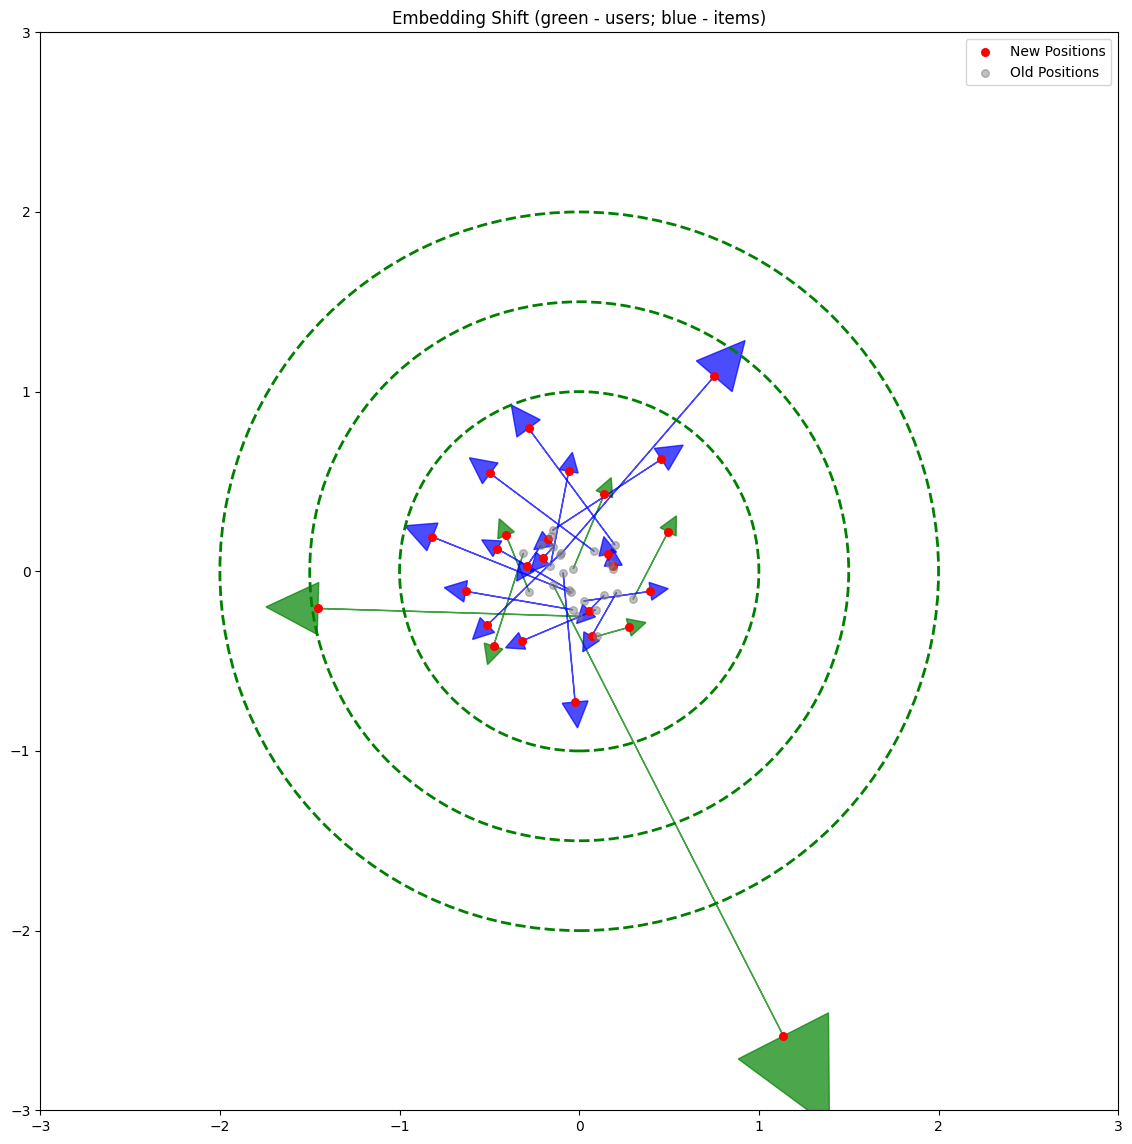

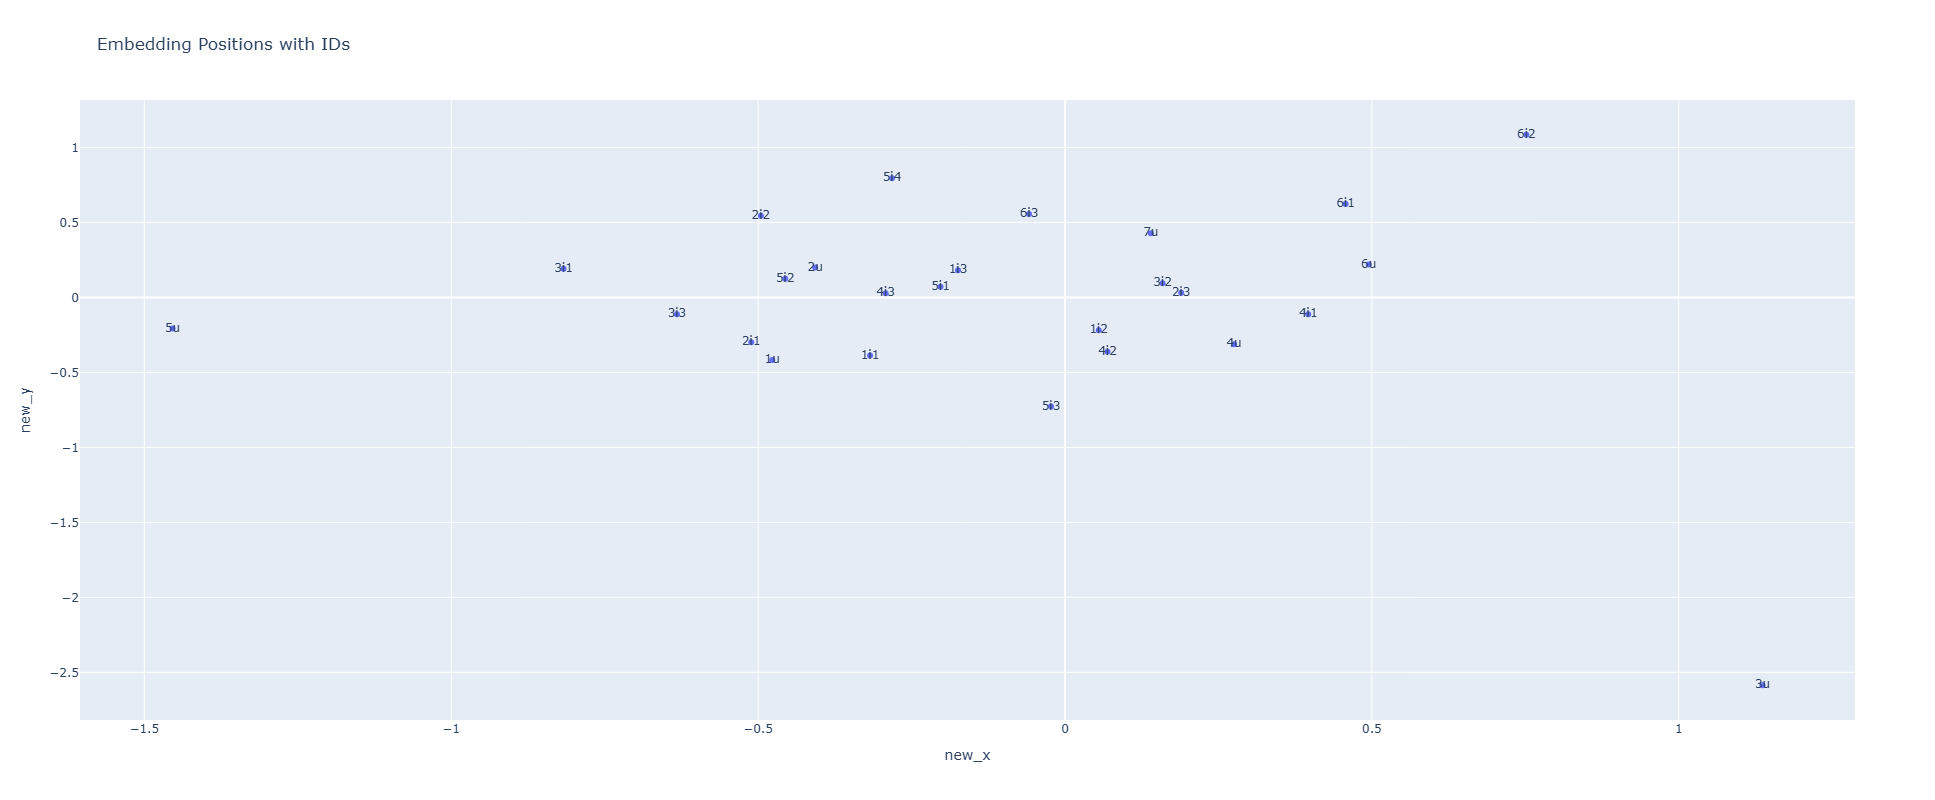

Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

Train loss: 3.102382183074951
Fraction of strictly orthogonal gradients (users): 1.0
Fraction of strictly orthogonal gradients (items): 1.0


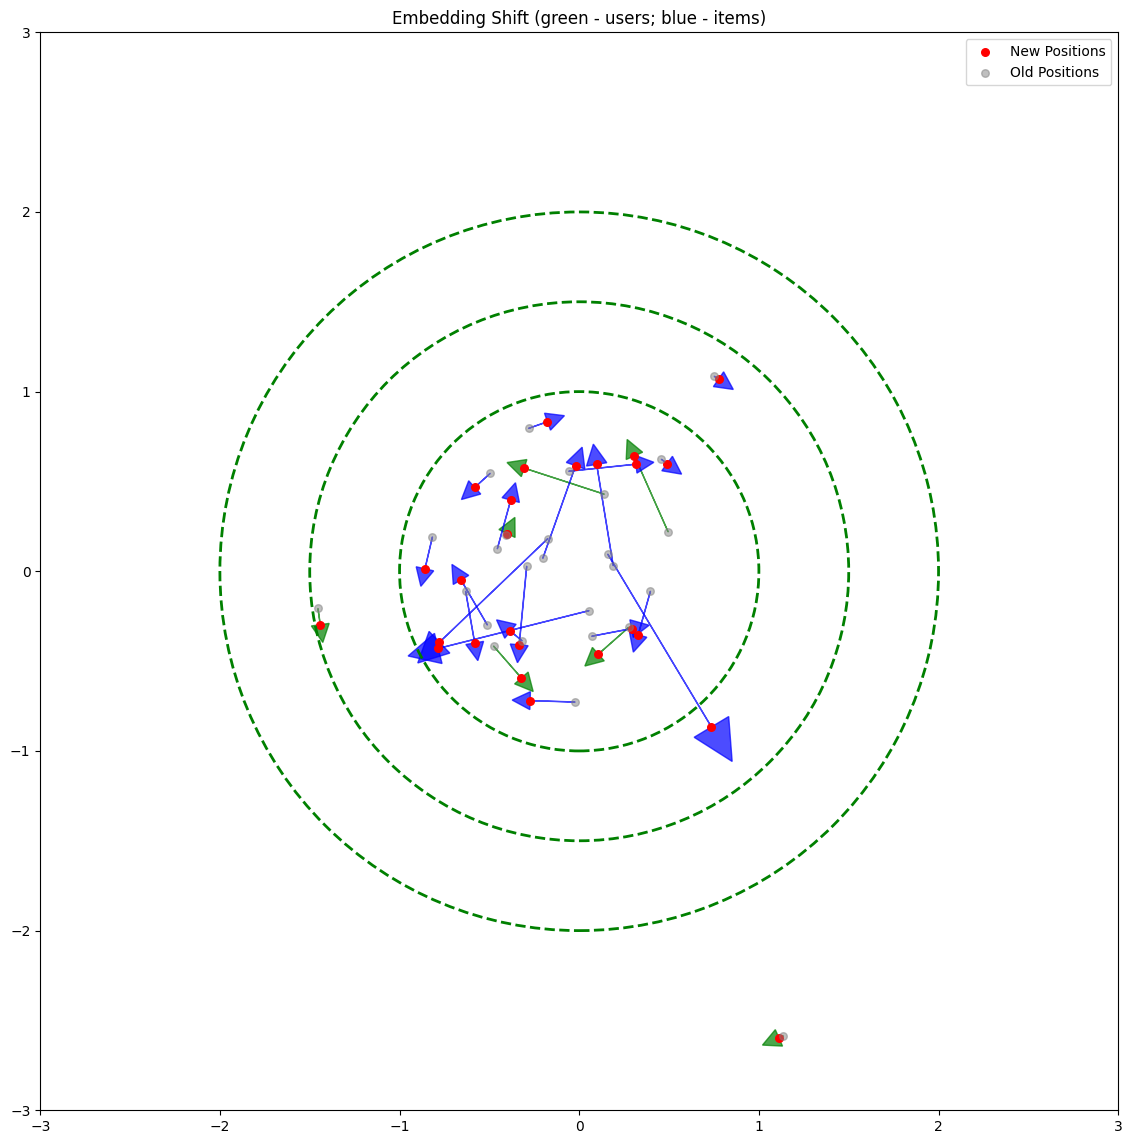

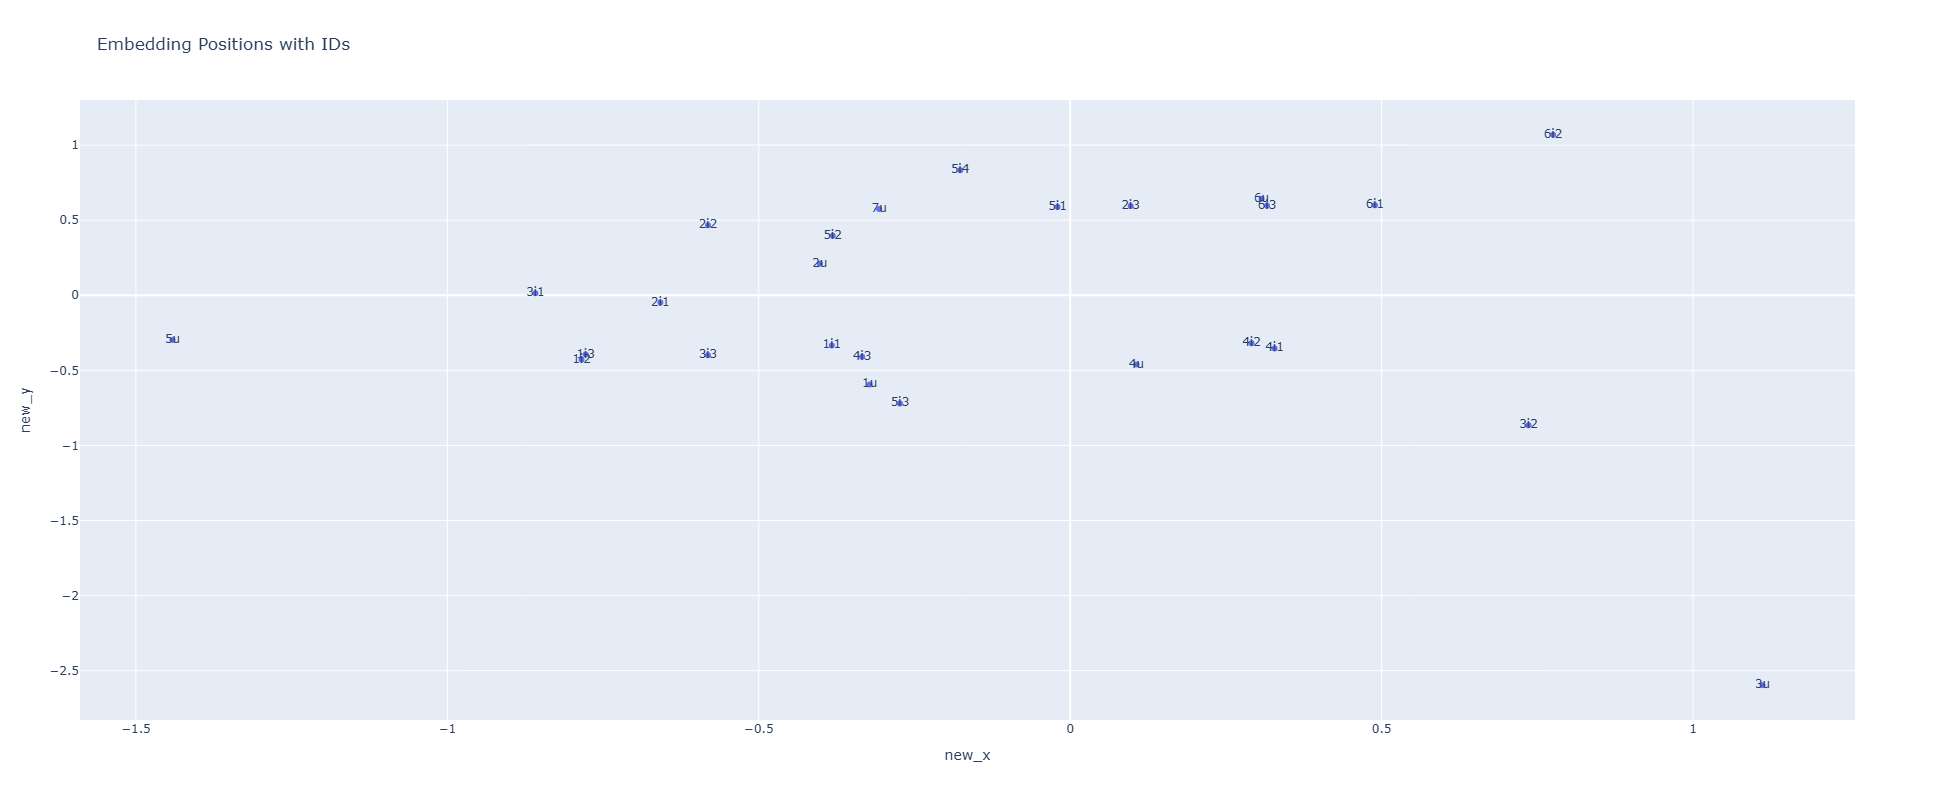

Epoch 2:   0%|          | 0/1 [00:00<?, ?it/s]

Train loss: 2.880051612854004
Fraction of strictly orthogonal gradients (users): 1.0
Fraction of strictly orthogonal gradients (items): 1.0


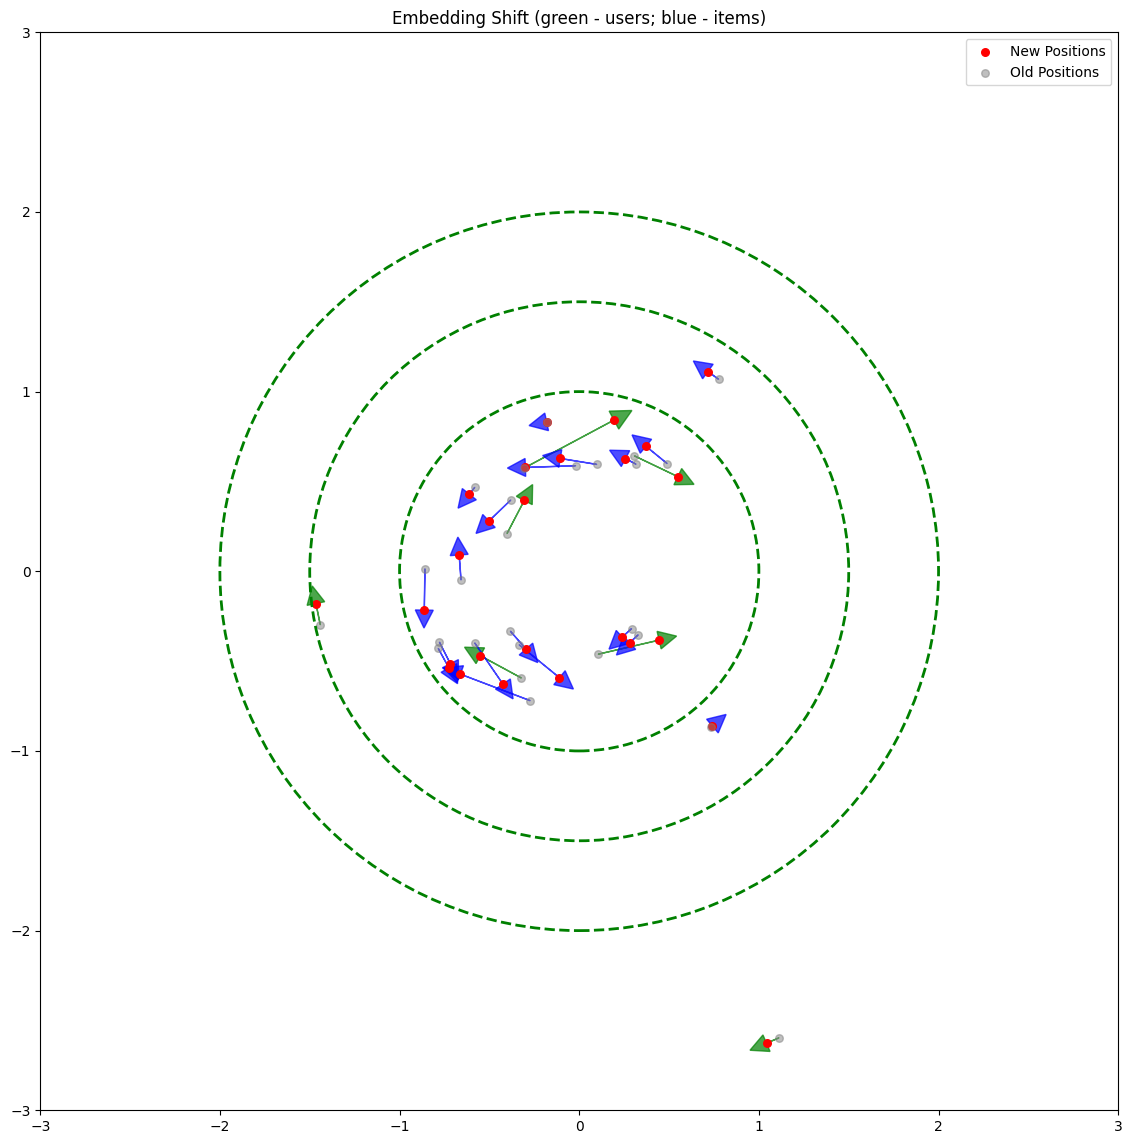

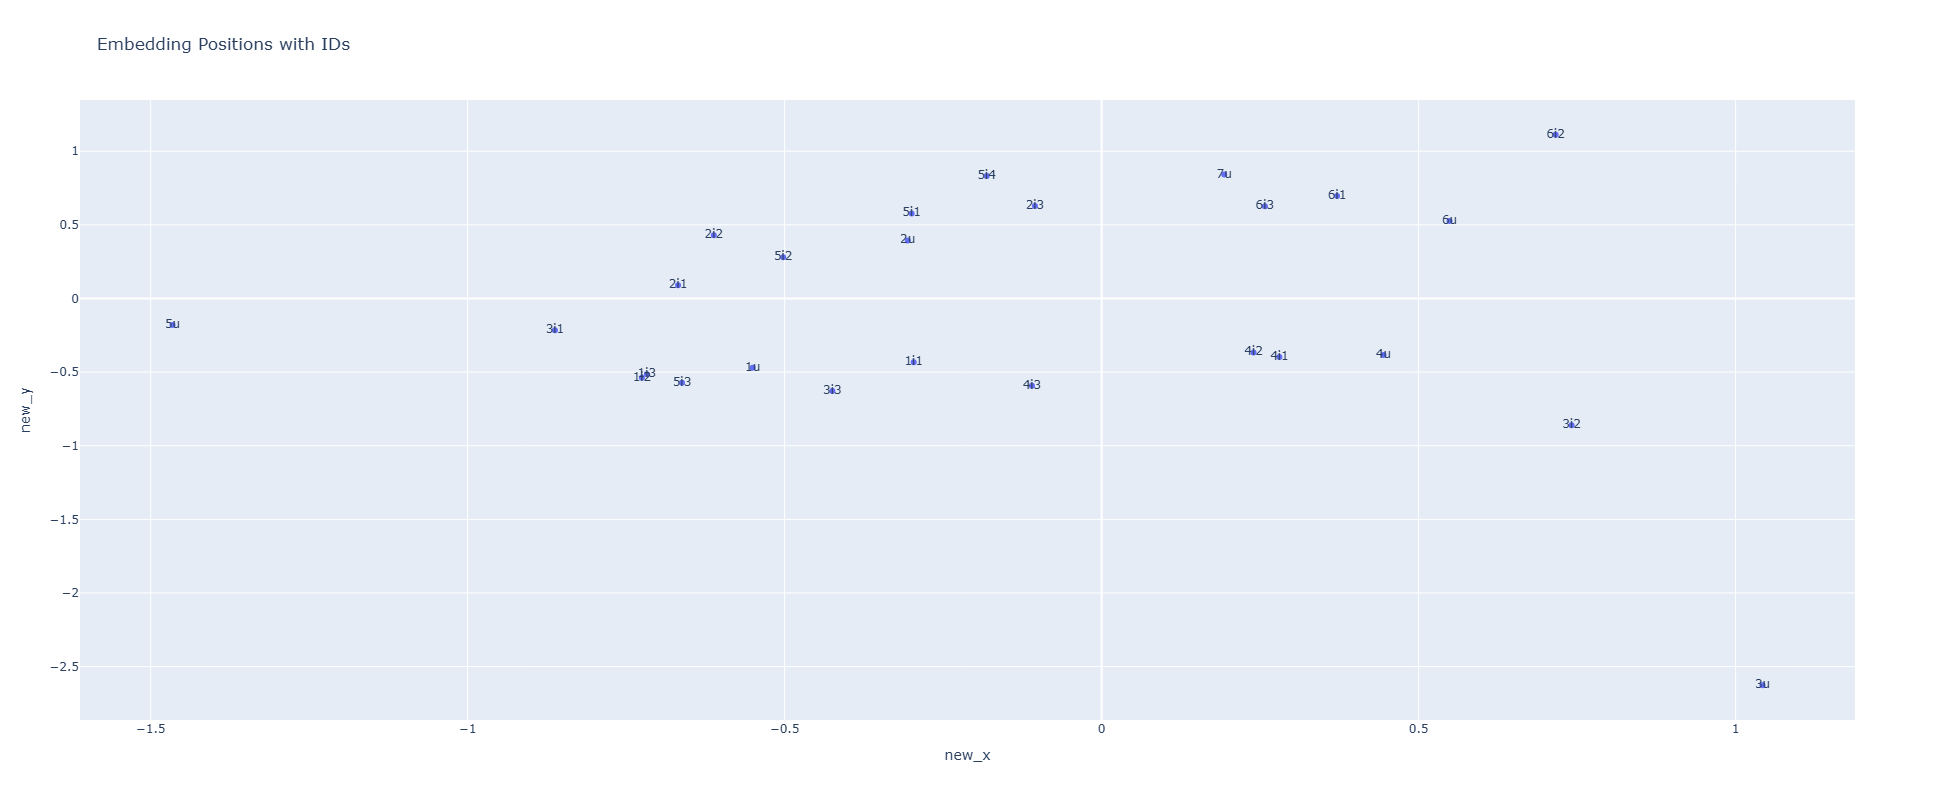

Epoch 99:   0%|          | 0/1 [00:00<?, ?it/s]

Train loss: 2.5219757556915283
Fraction of strictly orthogonal gradients (users): 1.0
Fraction of strictly orthogonal gradients (items): 1.0


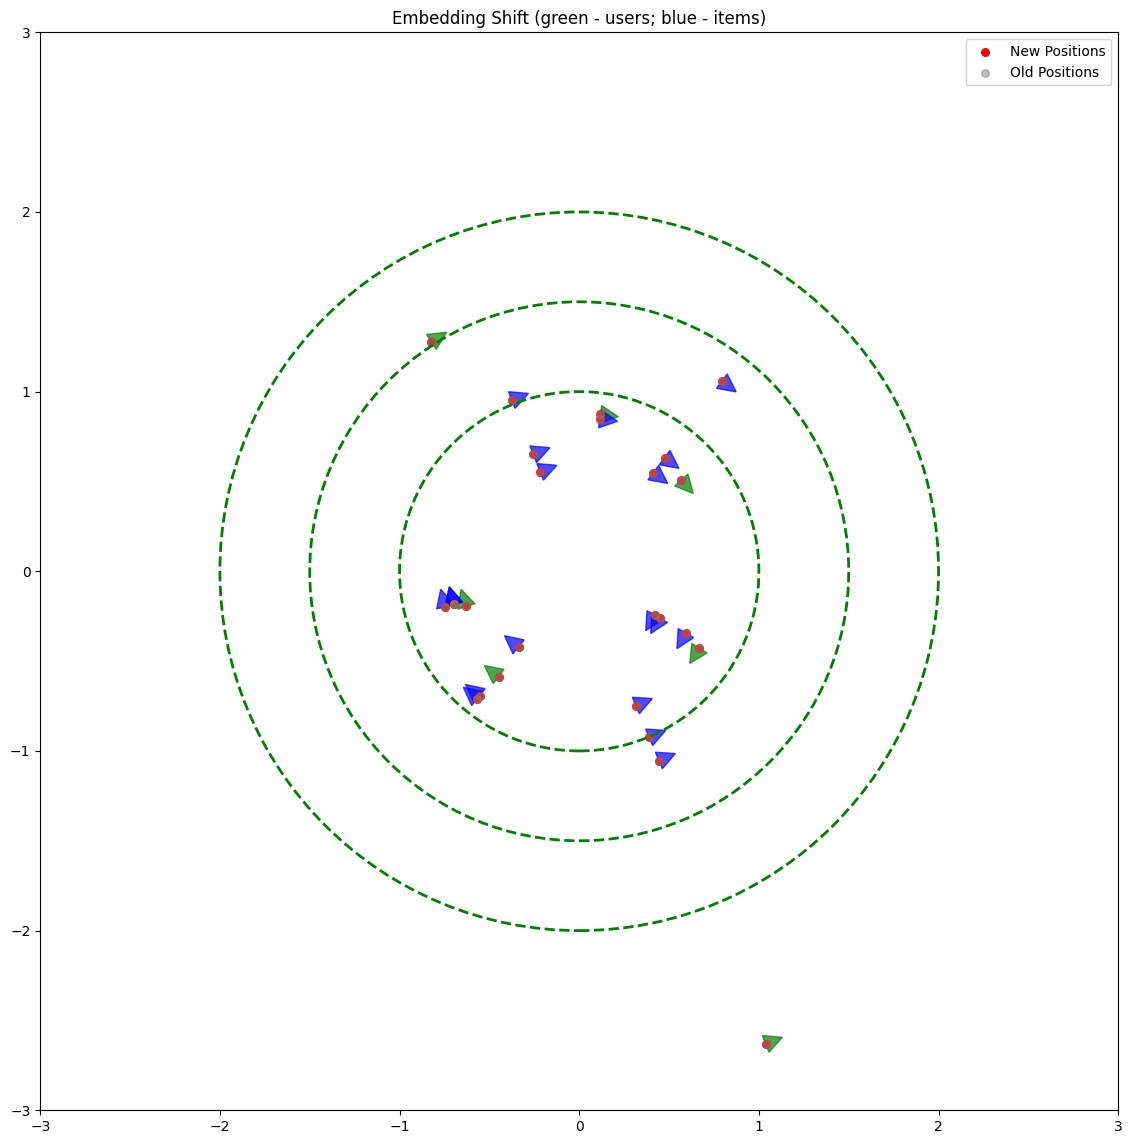

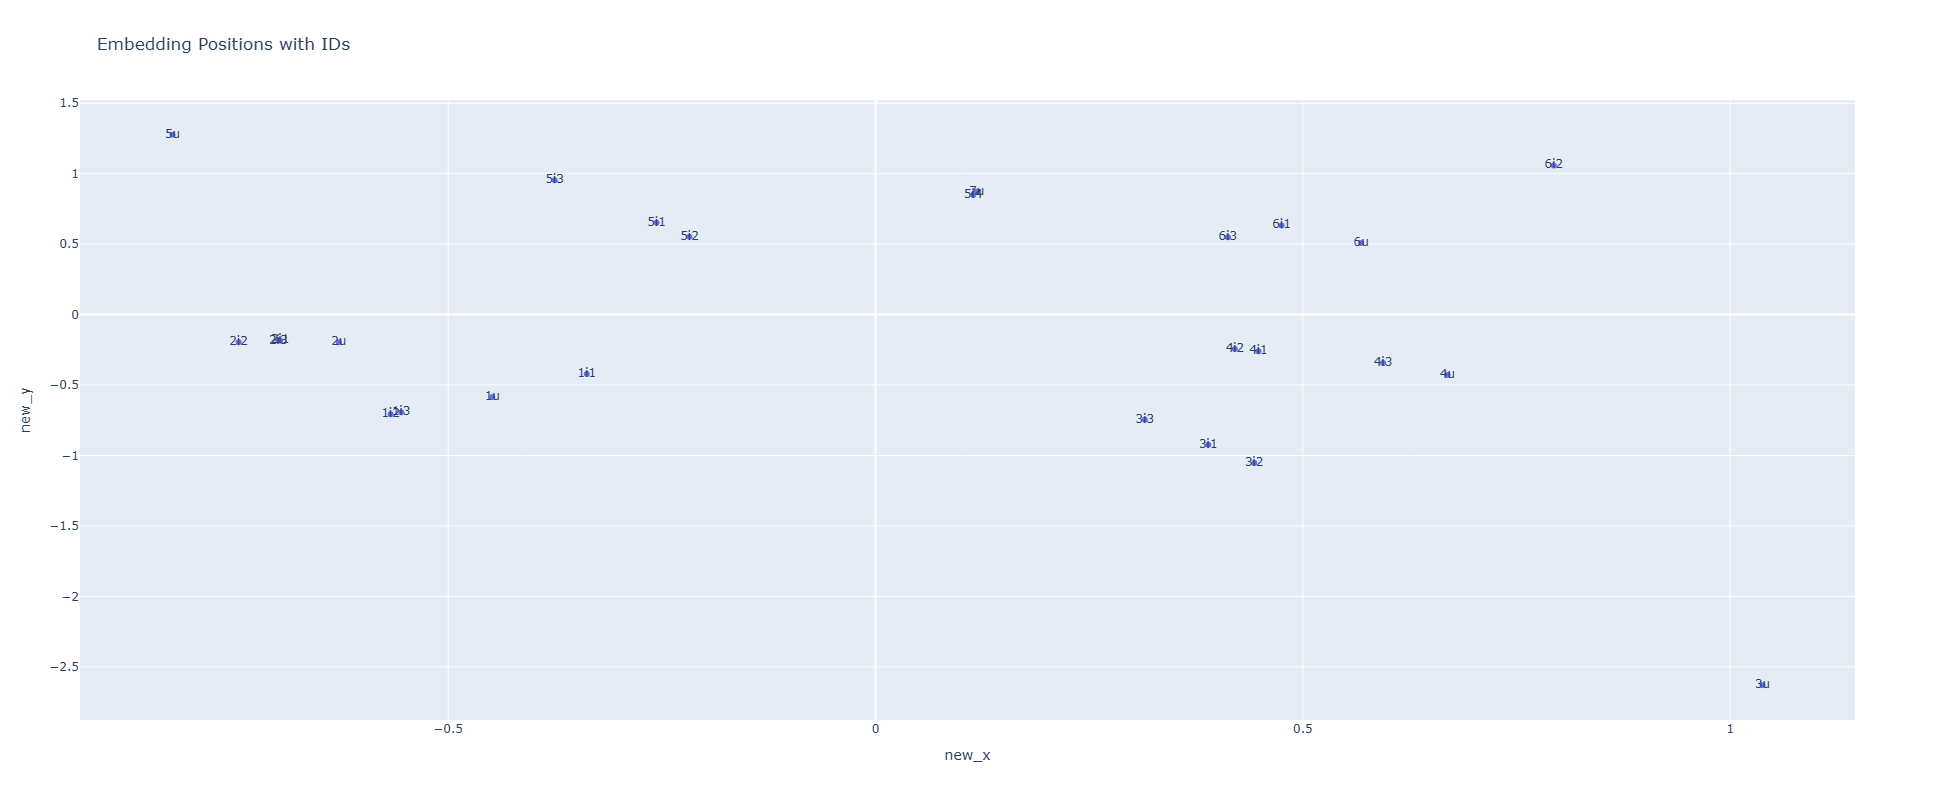

Epoch 99: 100%|██████████| 1/1 [00:00<00:00,  6.01it/s]


In [8]:
user_embedding_sizes = [len(user_encoder.classes_), 2]
item_embedding_sizes = [len(item_encoder.classes_), 2]

model = TwoTowerModel(user_embedding_sizes, item_embedding_sizes, 
                      device).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=5, momentum=0)

users_ids, users_features = zip(*train_dataset.user2features.items())
items_ids, items_features = zip(*train_dataset.item2features.items())

users_features = torch.IntTensor(np.array(users_features)).squeeze(1)
items_features = torch.IntTensor(np.array(items_features)).squeeze(1)

users_features = F.one_hot(users_features.long(), num_classes=N_USERS).float()
items_features = F.one_hot(items_features.long(), num_classes=N_ITEMS).float()

def train_loop(model, optimizer, train_loader, n_epochs=100):
    loss_history = list()
    for epoch in range(n_epochs):
        for batch in tqdm(train_loader, desc=f'Epoch {epoch}'):
            
            user_embs, item_embs = model(*batch)
            loss = infonceloss(user_embs, item_embs)

            optimizer.zero_grad()
            loss.backward()

            old_users_embeddings = model.get_user_embeddings(
                torch.FloatTensor(np.array(users_features)).to(device)
            )
            old_items_embeddings = model.get_item_embeddings(
                torch.FloatTensor(np.array(items_features)).to(device)
            )

            optimizer.step()

            new_users_embeddings = model.get_user_embeddings(
                torch.FloatTensor(np.array(users_features)).to(device)
            )
            new_items_embeddings = model.get_item_embeddings(
                torch.FloatTensor(np.array(items_features)).to(device)
            )

            loss_history.append(loss.item())
            
            if (epoch < 3) or (epoch == 99):
                print(f'Train loss: {loss_history[-1]}')
                plot_embedding_shift(
                    old_users_embeddings,
                    old_items_embeddings,
                    new_users_embeddings,
                    new_items_embeddings,
                    users_ids,
                    items_ids,
                    title="Embedding Shift (green - users; blue - items)"
                )

model.train()
train_loop(model, optimizer, train_loader)